In [1]:
#Imports, Variables and Configs
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

spreadsheet_export_link="https://docs.google.com/spreadsheets/d/1OE4CGMRYlF4HXECkARKOz8WyxHFl31YHNCrU8mdyl_Y/export?format=csv"


In [2]:
#creating pandas DF
df = pd.read_csv(spreadsheet_export_link)

#testing if sheet is sucessfully imported
df

,Carimbo de data/hora,Linkedin,Nome,Area de Atuação / Area de Interesse,Quando entrou na FATEC?,Uma breve descrição sobre você com seus objetivos,Stack / Tecnologias / Conhecimentos,Senioridade,Coluna 6
0,24/02/2025 14:49:30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,24/02/2025 14:50:55,https://www.linkedin.com/in/caiombr/,Caio Marques Bittencourt Ribeiro,Dados,24/08/2023,"Atuo com Governança de Dados, Análise de Dados...",NaN,Junior,NaN
2,24/02/2025 14:57:11,https://www.linkedin.com/in/guilherme-alves-no...,Guilherme Alves Nogueira,Suporte/back ou frontend,01/07/2024,"Iniciei minha trajetória profissional em 2017,...",NaN,Estágio/Júnior,NaN
3,24/02/2025 15:04:24,https://www.linkedin.com/in/patricknatan/,Patrick,Desenvolvimento WEB,01/07/2018,NaN,NaN,Pleno,NaN
4,24/02/2025 15:16:31,https://www.linkedin.com/in/joaopgaldino/,João Galdino,Backend,01/07/2024,"Java, Kotlin, SQL, NoSQL, Angular, APIs, Kafka...",NaN,Backend,NaN
5,24/02/2025 15:17:22,https://www.linkedin.com/in/ana-c-b-do-nascime...,Ana Carolina Borges do Nascimento,Júnior,01/08/2023,"Atualmente atuo com mainframe com cobol, natur...",NaN,Junior,NaN
6,24/02/2025 15:34:06,www.linkedin.com/in/henri-salvador-alves/,Henri Salvador Afonso Alves,Aprendiz Administrativo,09/08/2023,Busco ser desenvolvedor no BackEnd. Minha lin...,NaN,NaN,NaN
7,24/02/2025 15:34:18,www.linkedin.com/in/hferrazdev,Henrique Ferraz,Desenvolvimento Web Full Stack,10/02/2025,Atualmente focado no aprendizado de React e No...,NaN,Estágio,NaN
8,24/02/2025 15:51:08,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,24/02/2025 16:10:13,https://www.linkedin.com/in/enzo-oliveira-malz...,Enzo Oliveira Malzone,Governança de TI,01/08/2024,Sou uma pessoa muito dedicada aos meus objetiv...,Python/SQL/PowerBI/VBA/LabView/Arduino/SolidWo...,Estagio,NaN


In [3]:
#creating clean df for analysis
df_analise = df[['Nome','Area de Atuação / Area de Interesse','Quando entrou na FATEC?','Uma breve descrição sobre você com seus objetivos','Stack / Tecnologias / Conhecimentos','Senioridade']]

#renaming columns for easier data manipulation
df_analise = df_analise.rename(columns={'Nome':'nome','Area de Atuação / Area de Interesse':'area','Quando entrou na FATEC?':'data_admissão','Uma breve descrição sobre você com seus objetivos':'descrição','Stack / Tecnologias / Conhecimentos':'hard_skills','Senioridade':'senioridade'})

#creating a clean df with either NaN nor Empty values in hard_skills and seniority columns
df_analise_clean = df_analise.dropna(subset=['hard_skills','senioridade']).copy()

#setting column types
df_analise_clean['data_admissão'] = pd.to_datetime(df_analise_clean['data_admissão'],dayfirst=True)

#check if it's working
df_analise_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 9 to 40
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   nome           28 non-null     object        
 1   area           28 non-null     object        
 2   data_admissão  28 non-null     datetime64[ns]
 3   descrição      27 non-null     object        
 4   hard_skills    28 non-null     object        
 5   senioridade    28 non-null     object        
dtypes: datetime64[ns](1), object(5)
memory usage: 1.5+ KB


In [4]:
df_analise_hsclean = df_analise_clean.copy()
#creating a new df with hard skills column normalized for statistics purposes
df_analise_hsclean['hard_skills'] = df_analise_clean['hard_skills'].str.replace(r'\s*\|\s*|/', ',', regex=True).copy()
df_analise_hsclean['hard_skills'] = df_analise_hsclean['hard_skills'].str.replace(r',\s+', ', ', regex=True)
df_analise_hsclean['hard_skills'] = df_analise_hsclean['hard_skills'].str.replace(r',\s*', ', ', regex=True)

#setting datetime datatype
df_analise_hsclean['data_admissão'] = pd.to_datetime(df_analise_hsclean['data_admissão'],dayfirst=True)
#confirm datatype
df_analise_hsclean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 9 to 40
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   nome           28 non-null     object        
 1   area           28 non-null     object        
 2   data_admissão  28 non-null     datetime64[ns]
 3   descrição      27 non-null     object        
 4   hard_skills    28 non-null     object        
 5   senioridade    28 non-null     object        
dtypes: datetime64[ns](1), object(5)
memory usage: 1.5+ KB


In [5]:
display(df_analise_hsclean.sort_values('data_admissão'))

,nome,area,data_admissão,descrição,hard_skills,senioridade
40,Eric,Dados,2019-01-01,Expandir a rede,"Python, Plataformas cloud, SQL, Bibliotecas",Junior
33,Matheus Bonfim,Backend,2019-01-10,Sou formado no ensino técnico de informática p...,"Python, Javascript, Java, HTML, CSS, NodeJS, D...",Junior
24,Karen Gabriella,Desenvolvimento de Automações - RPA Python,2021-02-16,Sou uma pessoa apaixonada por inovação e justi...,"Java, Python, PHP, Node.js, JavaScript, RPA, D...",Junior
13,João Wictor Leles,Desenvolvedor Web - Pleno,2022-02-07,Programador jovem entusiasta em Negócios Digit...,".NET Core, Arquitetura DDD, API REST, SQL Serv...",Pleno
21,Rai Mello,WEB Development,2022-02-07,Pretendo aprender o máximo possível tecnologia...,"JS, Angular, componentes, API, SQL, FIGMA, KAN...",Estagio
14,Jean Sousa,"Suporte, Infra, DevOps, Cloud",2022-08-01,Buscando um pouco de cada área mas no momento ...,"Spring, Linux, Git, Python",Junior
34,Davi Fernandes,Análise de dados,2022-08-01,Sou analista de dados. Entendo da parte de mon...,"Phyton, C, PowerBI",Estagio
17,Jean Carlos,Programador RPA,2022-08-08,Tenho experiencia com RPA e desenvolvimento de...,"Python, Cobol",Junior
36,Daniel Ferreira Santana,SRE,2022-08-15,NaN,"Node, typescript, angular, Java, python, html,...",Estagio
27,Luiz Henrique de Santana,Desenvolvedor Fullstack / Android,2023-01-01,Sou desenvolvedor de software com experiência ...,"Java (Spring Boot), APIs REST, SQL (MySQL, SQL...",Junior


In [6]:
import pandas as pd
from collections import Counter
from fuzzywuzzy import fuzz

# function to standardize technologies using fuzzy matching (levenhstein)
def standardize_technologies(df, column_name='hard_skills', similarity_threshold=80):
    # lowercase everything first
    df[column_name] = df[column_name].str.lower()
    
    all_techs = []
    for tech_list in df[column_name]:
        techs = [t.strip() for t in tech_list.split(',')]
        all_techs.extend(techs)

    tech_counter = Counter(all_techs)
    tech_clusters = {}
    processed = set()

    for tech, count in tech_counter.most_common():
        if tech in processed:
            continue
        cluster = [tech]
        processed.add(tech)
        for other_tech, other_count in tech_counter.items():
            if other_tech in processed:
                continue
            similarity = fuzz.ratio(tech, other_tech)
            if similarity >= similarity_threshold:
                cluster.append(other_tech)
                processed.add(other_tech)
        if len(cluster) > 1:
            sub_counter = Counter([t for t in all_techs if t in cluster])
            canonical = sub_counter.most_common(1)[0][0]
            tech_clusters[canonical] = cluster

#function to 
    def standardize_techs(tech_string):
        techs = [t.strip() for t in tech_string.split(',')]
        for i, tech in enumerate(techs):
            for canonical, cluster in tech_clusters.items():
                if tech in cluster:
                    techs[i] = canonical
                    break
        return ', '.join(techs)

    df['hard_skills_standardized'] = df[column_name].apply(standardize_techs)
    return df

# apply the standardization
df_analise_standardized = standardize_technologies(df_analise_hsclean)

In [7]:
df_analise_standardized

,nome,area,data_admissão,descrição,hard_skills,senioridade,hard_skills_standardized
9,Enzo Oliveira Malzone,Governança de TI,2024-08-01,Sou uma pessoa muito dedicada aos meus objetiv...,"python, sql, powerbi, vba, labview, arduino, s...",Estagio,"python, sql, powerbi, vba, labview, arduino, s..."
10,Wallace Rosendo,"Backend, Mobile e Cibersegurança",2023-07-01,Programador altamente motivado com uma paixão ...,"go, java, kotlin, ruby, sql, git",Estagio,"go, java, kotlin, ruby, sql, git"
11,Christian Vicente Kaloupis,Desenvolvimento e dados,2023-02-06,Atualmente meu principal objetivo é ingressar ...,"c#, java, python, sql, pl, sql, pandas, r, ora...",Estagio,"c#, java, python, sql, pl, sql, pandas, r, ora..."
12,Inácio,Machine Learning e Fullstack,2024-02-02,"Sou um músico amigável, que também ama program...","ruby on rails, flutter, reactjs, nodejs, mysql...",Junior,"ruby on rails, flutter, reactjs, nodejs, mysql..."
13,João Wictor Leles,Desenvolvedor Web - Pleno,2022-02-07,Programador jovem entusiasta em Negócios Digit...,".net core, arquitetura ddd, api rest, sql serv...",Pleno,".net core, arquitetura ddd, api rest, sql serv..."
14,Jean Sousa,"Suporte, Infra, DevOps, Cloud",2022-08-01,Buscando um pouco de cada área mas no momento ...,"spring, linux, git, python",Junior,"spring, linux, git, python"
16,Henri Salvador Afonso Alves,Back-End Developer,2023-08-23,Busco ser desenvolvedor no BackEnd. Minha lin...,"python, vba, java, sql",Estagio,"python, vba, java, sql"
17,Jean Carlos,Programador RPA,2022-08-08,Tenho experiencia com RPA e desenvolvimento de...,"python, cobol",Junior,"python, cobol"
19,Lucas Campos,Estágio Backend / Cybersec,2024-03-03,Estudando Backend à procura de um Estágio. Gos...,".net c#, python, linux, sql, c",Estagio,".net c#, python, linux, sql, c"
20,Guilherme Marinho Bernardi,Desenvolvedor C# JR voltado a SAP Business One...,2023-09-01,"Estudo computação desde 2021, gosto de aprende...",unicamp - sistemas da informação (2021-2022)\n...,Junior,unicamp - sistemas da informação (2021-2022)\n...


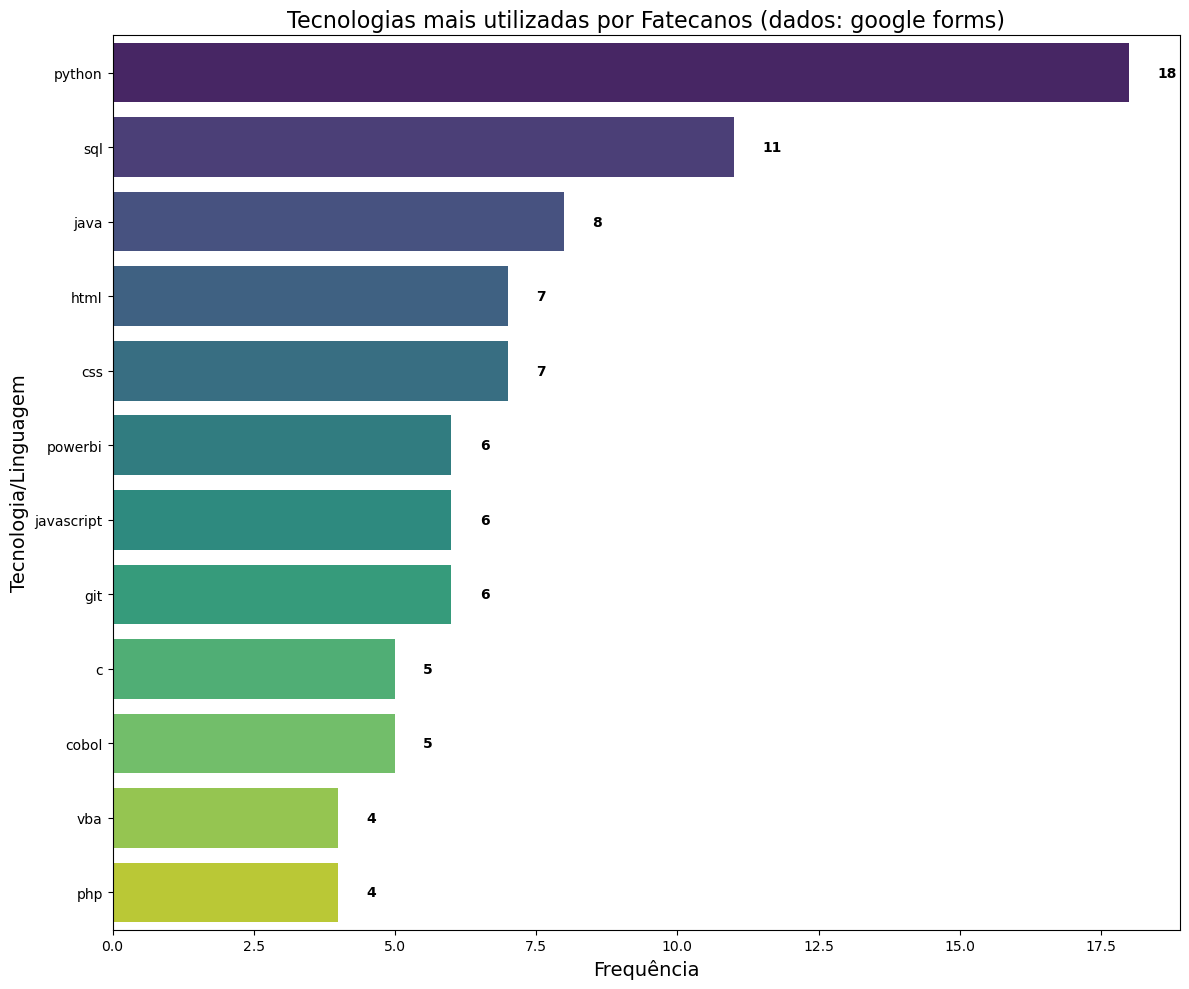

In [11]:
import seaborn as sns
#plot the most used technologies/hard skills between FATEC SP ADS students
all_techs = []
for row in df_analise_hsclean['hard_skills_standardized']:
    techs = [t.strip() for t in row.split(',')]
    all_techs.extend(techs)
    
#manually setting some strings that have important languages/techs inside the string to the name itself (like: android(java ) becomes java etc.)
#for i, tech in enumerate(all_techs):
 #   if 'java' in tech.lower():
  #      techs[i] = replacement

tech_counts = Counter(all_techs)

# creating df for plotting
plot_df = pd.DataFrame({
    'Technology': list(tech_counts.keys()),
    'Count': list(tech_counts.values())
})

plot_df = plot_df.sort_values('Count', ascending=False)

# plotting the top technologies
top_n = 12
top_techs = plot_df.head(top_n)


plt.figure(figsize=(12, 10))
ax = sns.barplot(x='Count', y='Technology', hue='Technology', data=top_techs, palette='viridis', legend=False)
for i, v in enumerate(top_techs['Count']):
    ax.text(v + 0.5, i, str(v), va='center', fontweight='bold', fontsize=10, color='black')
plt.title(f'Tecnologias mais utilizadas por Fatecanos (dados: google forms)', fontsize=16)
plt.xlabel('Frequência', fontsize=14)
plt.ylabel('Tecnologia/Linguagem', fontsize=14)
plt.tight_layout()
plt.show()


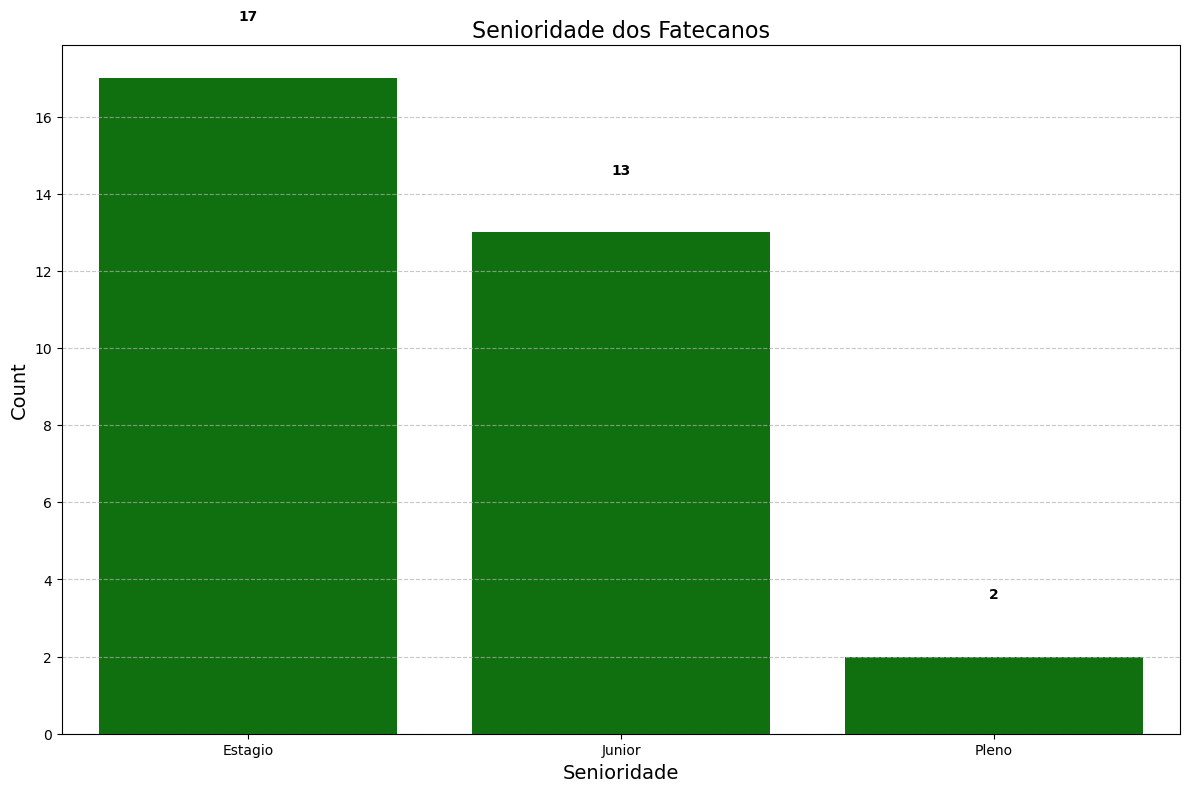

In [13]:
#plot of seniority

seniority_counts = df_analise['senioridade'].value_counts().reset_index().head(3)
seniority_counts.columns = ['senioridade', 'Count']

plt.figure(figsize=(12, 8))

ax = sns.barplot(x='senioridade',y='Count', data=seniority_counts, color='green')

for i, v in enumerate(seniority_counts['Count']):
    ax.text(i, v + 1.5, str(v), ha='center', fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.title('Senioridade dos Fatecanos', fontsize=16)
plt.xlabel('Senioridade', fontsize=14)
plt.ylabel('Count', fontsize=14)
plt.tight_layout()
plt.show()